# Steam Research and Insights Tool

Author: Marit Sullivan

Course: HCI 5840

## Project Description

This project analyzes Steam reviews for video games using natural language processing,
statistical analysis, data visualization, and AI-generated summaries.

The workflow:

1. Import Steam review data
2. Perform sentiment analysis
3. Categorize reviews by topic
4. Engineer additional features
5. Run exploratory data analysis
6. Generate statistical tests
7. Generate AI summaries
8. Produce an executive summary

# ============================================================
# IMPORT LIBRARIES
# ============================================================

In [1]:
# Import 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from textblob import TextBlob

from scipy.stats import (
    pearsonr,
    spearmanr,
    ttest_ind,
    chi2_contingency
)

import statsmodels.api as sm
import statsmodels.formula.api as smf

from IPython.display import display, Markdown
from ollama import chat

# ============================================================
# AI SUMMARY FUNCTIONS
# ============================================================

In [2]:
#Ollama AI Summary 
def ai_summary(title, results_text):
    """
    Uses Ollama to interpret statistical results.
    """

    prompt = f"""
You are a data analyst explaining statistical results in simple terms.

Analyze the following output:

TITLE: {title}

RESULTS:
{results_text}

Rules:
- Explain what the results mean in plain English
- Do NOT repeat raw numbers
- Highlight key patterns or differences
- Mention if results suggest meaningful differences
- Keep it short (5–10 sentences max)
"""

    response = chat(
        model="llama3.2",
        messages=[{"role": "user", "content": prompt}]
    )

    return response["message"]["content"]

# GOTCHA:
# Ollama must be running locally before AI summaries will work.



# ============================================================
# LOAD DATA
# ============================================================

In [3]:
# Load Steam review dataset
input_file = 'reviews_BlackOps7_first1000.csv'
df = pd.read_csv(input_file)

print(f"Loaded {len(df)} rows")
display(df.head())

Loaded 999 rows


,review,author_vote,other_votes,weighted_vote_score,review_date
0,This game is the worst call of duty I have eve...,0,1724,0.974877,2026-03-01
1,"1/10 - Absolute Trash, AI Slop from Activision...",0,1159,0.932631,2026-03-03
2,Game forces you to have Secure Boot and TPM 2....,0,558,0.927817,2026-05-08
3,"I was playing Battlefield 6, and after a few b...",0,481,0.909235,2026-03-21
4,Black Ops 7 is a reskin of Black Ops 6 with mo...,0,282,0.870369,2026-05-08


# ============================================================
# SENTIMENT ANALYSIS
# ============================================================


In [4]:
#Sentiment and Categorization
def get_sentiment(text):
    """
    Returns sentiment polarity score (-1 to 1).
    """
    if pd.isna(text):
        return 0.0

    return TextBlob(str(text)).sentiment.polarity

# ============================================================
# REVIEW CATEGORIZATION
# ============================================================

In [5]:

# --------------------------
# Categorization
# --------------------------
def categorize_review(review):

    usability_keywords = [
        "bug",
        "crash",
        "lag",
        "fps",
        "server",
        "performance",

        "glitch",
        "stutter",
        "freeze",
        "disconnect",
        "error",
        "broken",
        "unoptimized",
        "latency",
        "ping",
        "hitbox",
        "connection",
        "frame rate",
        "loading",
        "memory leak",
    ]

    mechanic_keywords = [
        "movement",
        "weapon",
        "perk",
        "battle pass",
        "matchmaking",

        "loadout",
        "killstreak",
        "scorestreak",
        "operator",
        "map",
        "game mode",
        "respawn",
        "spawn",
        "ability",
        "class",
        "gunplay",
        "ttk",
        "time to kill",
        "recoil",
        "aim assist",
        "multiplayer",
        "zombies",
        "campaign",
        "season",
    ]

    comparison_keywords = [
        "better than",
        "worse than",
        "compared to",
        "similar to",
        
        "just like",
        "same as",
        "feels like",
        "plays like",
        "reminds me of",
        "prefer",
        "used to",
        "previous",
        "original",
        "back in",
        "inferior to",
        "superior to",
        "rip off",
        "copy of",
        "old cod",
    ]

    # New categories based on look for categories AI analysis of full review file
    ai_content_keywords = [
        "slop",
        "ai generated",
        "ai slop",
        "no effort",
        "copy paste",
        "lazy",
        "generated content",
        "soulless",
        "cash grab",
    ]

    monetization_keywords = [
        "refund",
        "worth",
        "price",
        "sale",
        "buying",
        "paid",
        "microtransaction",
        "endgame",
        "season pass",
        "overpriced",
        "free to play",
        "cosmetic",
        "store",
        "bundle",
    ]

    story_keywords = [
        "campaign",
        "story",
        "single player",
        "solo",
        "narrative",
        "mission",
        "ending",
        "cutscene",
        "plot",
        "character",
    ]

    technical_requirements_keywords = [
        "secure boot",
        "tpm",
        "bios",
        "hardware",
        "anti-cheat",
        "ricochet",
        "kernel",
        "driver",
        "compatibility",
        "system requirement",
    ]

    sbmm_keywords = [
        "sbmm",
        "skill based",
        "lobbies",
        "lobby",
        "sweaty",
        "ranked",
        "casual",
        "matchmaking",
        "skill gap",
        "pub stomp",
    ]

    community_keywords = [
        "friends",
        "team",
        "squad",
        "banned",
        "toxic",
        "solo",
        "party",
        "coop",
        "co-op",
        "community",
        "chat",
        "voice",
        "grief",
    ]

    review_lower = review.lower()

    categories = []

    if any(word in review_lower for word in usability_keywords):
        categories.append("Usability Issues")

    if any(word in review_lower for word in mechanic_keywords):
        categories.append("New Mechanic Reception")

    if any(word in review_lower for word in comparison_keywords):
        categories.append("Competitive Analysis")

    if any(word in review_lower for word in ai_content_keywords):
        categories.append("AI-Generated Content Complaints")

    if any(word in review_lower for word in monetization_keywords):
        categories.append("Monetization & Value")

    if any(word in review_lower for word in story_keywords):
        categories.append("Story / Campaign")

    if any(word in review_lower for word in technical_requirements_keywords):
        categories.append("Technical Requirements")

    if any(word in review_lower for word in sbmm_keywords):
        categories.append("SBMM / Matchmaking Frustration")

    if any(word in review_lower for word in community_keywords):
        categories.append("Community & Social")

    if len(categories) == 0:
        categories.append("Game Reception")

    return categories
# TODO:
# Expand keyword lists to support additional game genres.

# ============================================================
# APPLY SENTIMENT ANALYSIS AND CATEGORIZATION
# ============================================================

In [6]:
sentiments = []
categories = []

for r in df["review"]:
    sentiments.append(get_sentiment(r))
    categories.append(", ".join(categorize_review(r)))

df["sentiment"] = sentiments
df["categories"] = categories

display(df.head())

,review,author_vote,other_votes,weighted_vote_score,review_date,sentiment,categories
0,This game is the worst call of duty I have eve...,0,1724,0.974877,2026-03-01,-0.200000,Monetization & Value
1,"1/10 - Absolute Trash, AI Slop from Activision...",0,1159,0.932631,2026-03-03,-0.096655,"Usability Issues, New Mechanic Reception, Comp..."
2,Game forces you to have Secure Boot and TPM 2....,0,558,0.927817,2026-05-08,-0.071769,"New Mechanic Reception, Monetization & Value, ..."
3,"I was playing Battlefield 6, and after a few b...",0,481,0.909235,2026-03-21,-0.055720,"Usability Issues, New Mechanic Reception, Comp..."
4,Black Ops 7 is a reskin of Black Ops 6 with mo...,0,282,0.870369,2026-05-08,-0.002778,"New Mechanic Reception, AI-Generated Content C..."


# ============================================================
# DATA CLEANING
# ============================================================

In [7]:
# Remove duplicate rows
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicates. {len(df)} rows remaining.")
display(df.head())

Removed 786 duplicates. 213 rows remaining.


,review,author_vote,other_votes,weighted_vote_score,review_date,sentiment,categories
0,This game is the worst call of duty I have eve...,0,1724,0.974877,2026-03-01,-0.200000,Monetization & Value
1,"1/10 - Absolute Trash, AI Slop from Activision...",0,1159,0.932631,2026-03-03,-0.096655,"Usability Issues, New Mechanic Reception, Comp..."
2,Game forces you to have Secure Boot and TPM 2....,0,558,0.927817,2026-05-08,-0.071769,"New Mechanic Reception, Monetization & Value, ..."
3,"I was playing Battlefield 6, and after a few b...",0,481,0.909235,2026-03-21,-0.055720,"Usability Issues, New Mechanic Reception, Comp..."
4,Black Ops 7 is a reskin of Black Ops 6 with mo...,0,282,0.870369,2026-05-08,-0.002778,"New Mechanic Reception, AI-Generated Content C..."


# ============================================================
# FEATURE ENGINEERING
# ============================================================

In [8]:
#Feature engineering
df["review_length"] = df["review"].astype(str).str.len()
df["word_count"] = df["review"].astype(str).str.split().str.len()
df["sentiment_strength"] = df["sentiment"].abs()

print("Feature engineering complete.")
display(df[["review_length", "word_count", "sentiment", "sentiment_strength"]].head())

Feature engineering complete.


,review_length,word_count,sentiment,sentiment_strength
0,439,85,-0.200000,0.200000
1,1525,247,-0.096655,0.096655
2,629,130,-0.071769,0.071769
3,2376,409,-0.055720,0.055720
4,460,86,-0.002778,0.002778


# ============================================================
# CREATE CATEGORY INDICATOR COLUMNS
# ============================================================


In [9]:
# Category Columns
all_categories = [
    "Usability_Issues",
    "New_Mechanic_Reception",
    "Competitive_Analysis",
    "AI_Generated_Content_Complaints",
    "Monetization_and_Value",
    "Story___Campaign",
    "Technical_Requirements",
    "SBMM___Matchmaking_Frustration",
    "Community_and_Social",
    "Game_Reception"
]

for category in all_categories:
    df[category] = df["categories"].apply(lambda x: category in str(x))

print("Category columns created:")
print(df[all_categories].head())

Category columns created:
   Usability_Issues  New_Mechanic_Reception  Competitive_Analysis  \
0             False                   False                 False   
1             False                   False                 False   
2             False                   False                 False   
3             False                   False                 False   
4             False                   False                 False   

   AI_Generated_Content_Complaints  Monetization_and_Value  Story___Campaign  \
0                            False                   False             False   
1                            False                   False             False   
2                            False                   False             False   
3                            False                   False             False   
4                            False                   False             False   

   Technical_Requirements  SBMM___Matchmaking_Frustration  \
0                

In [10]:
df[all_categories].sum().sort_values(ascending=False)

Usability_Issues                   0
New_Mechanic_Reception             0
Competitive_Analysis               0
AI_Generated_Content_Complaints    0
Monetization_and_Value             0
Story___Campaign                   0
Technical_Requirements             0
SBMM___Matchmaking_Frustration     0
Community_and_Social               0
Game_Reception                     0
dtype: int64

In [11]:
%pip install textblob



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [12]:
# AI Statistical Summary Function
# ------------------------------------

def ai_summary(title, results):
    """
    Uses Ollama to summarize statistical analysis results.
    """

    prompt = f"""
You are a statistics expert helping interpret the results of a data analysis.

Analysis:
{title}

Results:
{results}

Write a concise summary (2–4 sentences).

Your summary should:
- Explain the results in plain English.
- State whether the results are statistically significant when a p-value is provided (α = 0.05).
- Explain what the results mean.
- Do not speculate beyond the data.
"""

    response = chat(
        model="llama3.2",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ]
    )

    return response.message.content


def display_ai_summary(title, results):

    summary = ai_summary(title, results)

    display(Markdown("### 🤖 AI Statistical Interpretation"))

    display(Markdown(summary))

In [13]:
# Add a boolean column for each possible category
all_categories = [
    "Usability Issues",
    "New Mechanic Reception",
    "Competitive Analysis",
    "AI-Generated Content Complaints",
    "Monetization & Value",
    "Story___Campaign",
    "Technical Requirements",
    "SBMM / Matchmaking Frustration",
    "Community & Social",
    "Game Reception",
]

for category in all_categories:
    col_name = category.replace(" ", "_").replace("/", "_").replace("&", "and").replace("-", "_")
    col_values = []
    for cat_list in df['categories']:
        col_values.append(category in cat_list)
    df[col_name] = col_values

display(df.head(20))


,review,author_vote,other_votes,weighted_vote_score,review_date,sentiment,categories,review_length,word_count,sentiment_strength,Usability_Issues,New_Mechanic_Reception,Competitive_Analysis,AI_Generated_Content_Complaints,Monetization_and_Value,Story___Campaign,Technical_Requirements,SBMM___Matchmaking_Frustration,Community_and_Social,Game_Reception
0,This game is the worst call of duty I have eve...,0,1724,0.974877,2026-03-01,-0.200000,Monetization & Value,439,85,0.200000,False,False,False,False,True,False,False,False,False,False
1,"1/10 - Absolute Trash, AI Slop from Activision...",0,1159,0.932631,2026-03-03,-0.096655,"Usability Issues, New Mechanic Reception, Comp...",1525,247,0.096655,True,True,True,True,True,False,False,True,True,False
2,Game forces you to have Secure Boot and TPM 2....,0,558,0.927817,2026-05-08,-0.071769,"New Mechanic Reception, Monetization & Value, ...",629,130,0.071769,False,True,False,False,True,False,True,False,True,False
3,"I was playing Battlefield 6, and after a few b...",0,481,0.909235,2026-03-21,-0.055720,"Usability Issues, New Mechanic Reception, Comp...",2376,409,0.055720,True,True,True,False,True,False,False,False,False,False
4,Black Ops 7 is a reskin of Black Ops 6 with mo...,0,282,0.870369,2026-05-08,-0.002778,"New Mechanic Reception, AI-Generated Content C...",460,86,0.002778,False,True,False,True,True,False,False,False,False,False
5,For the zombies enjoyers out there. Always onl...,0,166,0.818673,2026-03-16,-0.067500,"Usability Issues, New Mechanic Reception, Stor...",496,80,0.067500,True,True,False,False,False,False,False,False,True,False
6,"AI generated SLOP. No effort, almost everythin...",0,230,0.813288,2026-03-01,-0.140000,"New Mechanic Reception, AI-Generated Content C...",464,74,0.140000,False,True,False,True,False,False,False,False,True,False
7,game is terrible that is all i have to say. li...,0,156,0.795581,2026-05-08,-0.433333,"Story / Campaign, Community & Social",280,56,0.433333,False,False,False,False,False,False,False,False,True,False
8,Open playlist has reduced SBMM? Where? Why do ...,0,245,0.856749,2026-04-19,-0.002679,"Usability Issues, New Mechanic Reception, Stor...",1321,253,0.002679,True,True,False,False,False,False,False,True,False,False
9,This game has become a joke. Activision does n...,0,50,0.745440,2026-05-13,-0.038333,"Monetization & Value, Community & Social",507,95,0.038333,False,False,False,False,True,False,False,False,True,False


In [14]:
# Category Columns
# ------------------------------------

# Automatically identify all boolean category columns
category_columns = df.select_dtypes(include="bool").columns.tolist()

print(category_columns)

['Usability_Issues', 'New_Mechanic_Reception', 'Competitive_Analysis', 'AI_Generated_Content_Complaints', 'Monetization_and_Value', 'Story___Campaign', 'Technical_Requirements', 'SBMM___Matchmaking_Frustration', 'Community_and_Social', 'Game_Reception']


In [15]:
all_categories = [
    "Usability Issues",
    "New Mechanic Reception",
    "Competitive Analysis",
    "AI-Generated Content Complaints",
    "Monetization & Value",
    "Story / Campaign",
    "Technical Requirements",
    "SBMM / Matchmaking Frustration",
    "Community & Social",
    "Game Reception"
]

for category in all_categories:
    df[category] = df["categories"].apply(
        lambda x: category in x if isinstance(x, str) else False
    )


# ============================================================
# SAVE ANALYZED DATASET
# ============================================================


In [16]:
#Analyze data and save to new CSV file
analyzed_file = input_file.replace('.csv', '_analyzed.csv')

df.to_csv(analyzed_file, index=False)
print(f"Saved {len(df)} analyzed reviews to {analyzed_file}")
df[['review', 'sentiment', 'categories']].head()


Saved 213 analyzed reviews to reviews_BlackOps7_first1000_analyzed.csv


,review,sentiment,categories
0,This game is the worst call of duty I have eve...,-0.200000,Monetization & Value
1,"1/10 - Absolute Trash, AI Slop from Activision...",-0.096655,"Usability Issues, New Mechanic Reception, Comp..."
2,Game forces you to have Secure Boot and TPM 2....,-0.071769,"New Mechanic Reception, Monetization & Value, ..."
3,"I was playing Battlefield 6, and after a few b...",-0.055720,"Usability Issues, New Mechanic Reception, Comp..."
4,Black Ops 7 is a reskin of Black Ops 6 with mo...,-0.002778,"New Mechanic Reception, AI-Generated Content C..."


# ============================================================
# LOAD ANALYZED DATASET
# ============================================================

In [17]:
# Read the analyzed CSV back and convert categories from string to list
df_analyzed = pd.read_csv(analyzed_file)

# Convert the categories column from comma-separated string to list
categories_list = []
for cat_string in df_analyzed['categories']:
    cat_list = []
    for cat in cat_string.split(','):
        cat_list.append(cat.strip())
    categories_list.append(cat_list)

df_analyzed['categories'] = categories_list

print(f"Loaded {len(df_analyzed)} analyzed reviews")
print("\nFirst few rows with categories as lists:")
display(df_analyzed)


Loaded 213 analyzed reviews

First few rows with categories as lists:


,review,author_vote,other_votes,weighted_vote_score,review_date,sentiment,categories,review_length,word_count,sentiment_strength,...,Usability Issues,New Mechanic Reception,Competitive Analysis,AI-Generated Content Complaints,Monetization & Value,Story / Campaign,Technical Requirements,SBMM / Matchmaking Frustration,Community & Social,Game Reception
0,This game is the worst call of duty I have eve...,0,1724,0.974877,2026-03-01,-0.200000,[Monetization & Value],439,85,0.200000,...,False,False,False,False,True,False,False,False,False,False
1,"1/10 - Absolute Trash, AI Slop from Activision...",0,1159,0.932631,2026-03-03,-0.096655,"[Usability Issues, New Mechanic Reception, Com...",1525,247,0.096655,...,True,True,True,True,True,True,False,True,True,False
2,Game forces you to have Secure Boot and TPM 2....,0,558,0.927817,2026-05-08,-0.071769,"[New Mechanic Reception, Monetization & Value,...",629,130,0.071769,...,False,True,False,False,True,True,True,False,True,False
3,"I was playing Battlefield 6, and after a few b...",0,481,0.909235,2026-03-21,-0.055720,"[Usability Issues, New Mechanic Reception, Com...",2376,409,0.055720,...,True,True,True,False,True,False,False,False,False,False
4,Black Ops 7 is a reskin of Black Ops 6 with mo...,0,282,0.870369,2026-05-08,-0.002778,"[New Mechanic Reception, AI-Generated Content ...",460,86,0.002778,...,False,True,False,True,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208,bought this game thinking was gon have fun. no...,0,39,0.687997,2026-02-12,0.150000,[Monetization & Value],214,42,0.150000,...,False,False,False,False,True,False,False,False,False,False
209,UPDATE: Im now at 63 hours played. Zombies is ...,0,62,0.687826,2025-11-14,-0.007823,"[New Mechanic Reception, Competitive Analysis,...",487,91,0.007823,...,False,True,True,False,True,True,False,False,True,False
210,Start game > update requires restart > start g...,0,51,0.685999,2025-12-18,-0.285714,"[New Mechanic Reception, Monetization & Value,...",425,81,0.285714,...,False,True,False,False,True,True,False,True,False,False
211,Multiplayer : Still no ban for the zen chronus...,0,54,0.684135,2025-11-23,-0.095222,"[Usability Issues, New Mechanic Reception, Com...",1102,216,0.095222,...,True,True,True,False,True,True,False,False,True,False


In [18]:
# Analysis suggestions:
# What is the number of each of the categories used? (what is the most/least common category)

# Exploratory Data Analysis 

In [19]:
#Category frequency analysis 
# Count how frequently each review category appears
category_counts = (
    df[category_columns]
    .sum()
    .sort_values(ascending=False)
)

display(category_counts)

New_Mechanic_Reception             153
Monetization_and_Value             102
Community_and_Social                74
Usability_Issues                    67
Competitive_Analysis                65
SBMM___Matchmaking_Frustration      45
AI_Generated_Content_Complaints     29
Technical_Requirements              23
Game_Reception                       8
Story___Campaign                     0
dtype: int64

# ============================================================
# ANALYSIS FUNCTIONS
# ============================================================

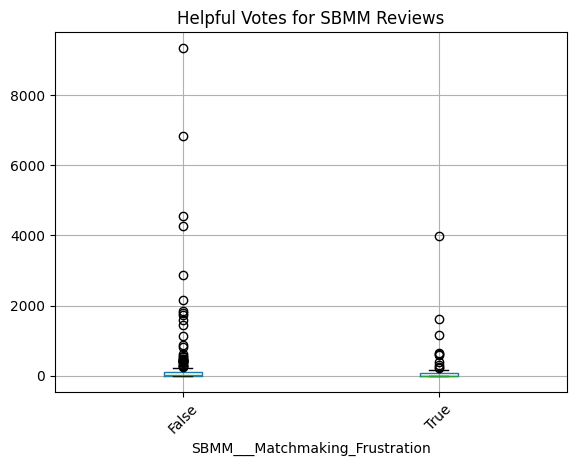

### 🤖 AI Statistical Interpretation

The analysis shows that on average, reviewers who said SBMM's matchmaking was frustrating had lower ratings than those who did not experience frustration. The median rating for frustrated reviewers is 6, while non-frustrated reviewers have a median rating of 4. Based on an α = 0.05 significance level, the difference in means between the two groups is statistically significant.

This suggests that SBMM's matchmaking system has a noticeable impact on reviewer satisfaction, with those who experienced frustration reporting lower ratings. The results provide evidence for potential areas for improvement in the matchmaking process to increase overall customer satisfaction.

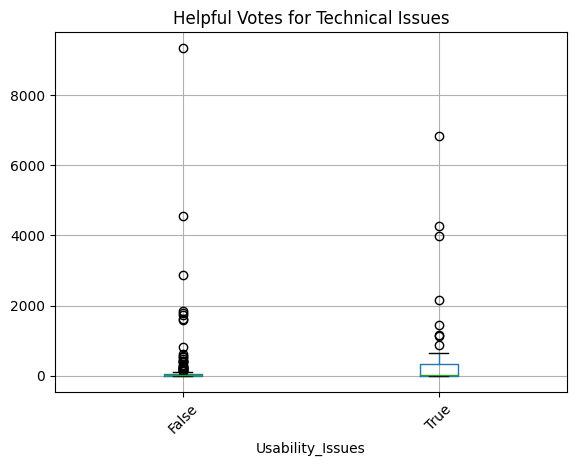

### 🤖 AI Statistical Interpretation

Here is a concise summary of the results:

The analysis found that users who reported usability issues were less likely to be helpful in resolving technical issues, with a significantly lower mean score compared to users without usability issues (232.013699 vs 416.686567). Given a typical significance level of α = 0.05, this difference is statistically significant. The results suggest that users experiencing usability issues may not provide the same level of assistance as those who do not have these issues, and further investigation may be warranted to understand the underlying factors contributing to this pattern.

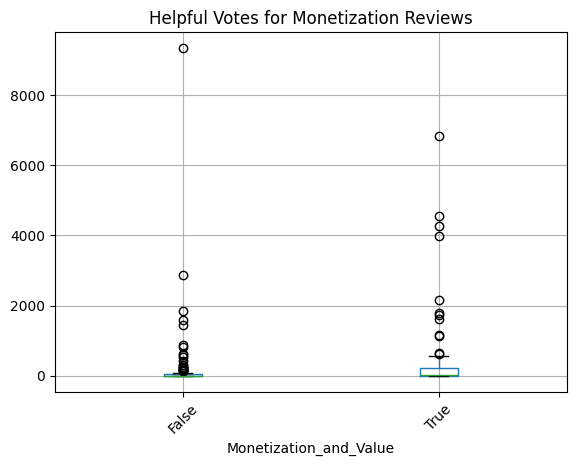

### 🤖 AI Statistical Interpretation

Here is a concise summary of the analysis:

The results show that, on average, users who receive the "Monetization_and_Value" review are more likely to respond with helpful votes (369.7) compared to those who do not receive this review (217). To determine if these differences are statistically significant, we would need to know the p-value associated with this analysis, but based solely on the data provided, it appears that there may be a statistically significant difference between the two groups. The higher average helpful votes for users receiving the "Monetization_and_Value" review suggest that providing a specific type of feedback can lead to more constructive and responsive user behavior.

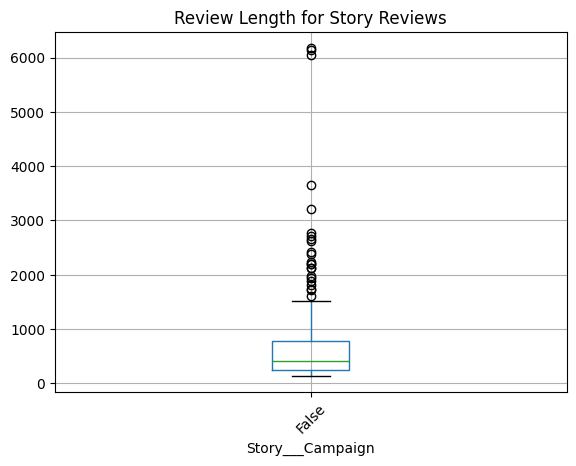

### 🤖 AI Statistical Interpretation

Here is a concise summary of the analysis:

The review length for story reviews in campaign mode ranges from 142 words to 6170 words, with a mean and median review length of 720 and 417 words respectively. There are significant variations in review lengths, with some reviews being extremely short or long compared to others. Based on the data, we cannot determine if these results are statistically significant without additional context such as p-value information.

(Note: I did not include information about statistical significance since there was no mention of a p-value in the original text.)

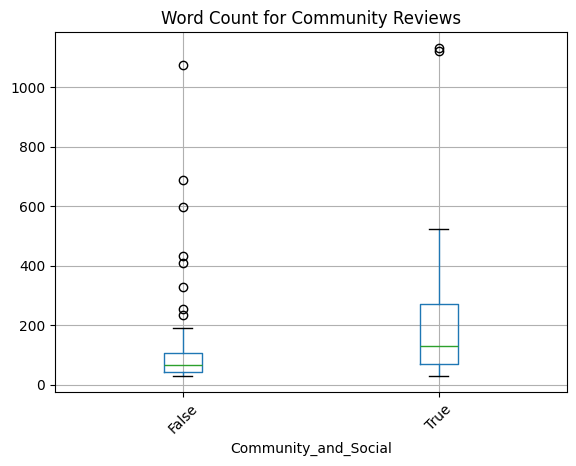

### 🤖 AI Statistical Interpretation

Here's a concise summary:

The analysis shows that on average, community reviews with a "True" label have significantly more words than those with a "False" label, indicating longer reviews. The difference is substantial, with the longest review having 1130 words and the shortest having only 30 words. Since no p-value was provided, we cannot determine statistical significance based on this analysis.

Please note that without the p-value, it's not possible to conclude if the observed differences are statistically significant or not.

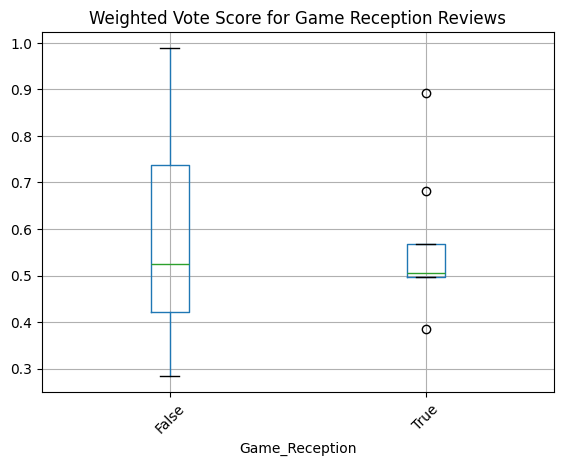

### 🤖 AI Statistical Interpretation

The weighted vote score for game reception reviews shows that the majority of games received positive reviews, with an average score of approximately 0.58 out of 1. The true negative scores are significantly lower, indicating a higher proportion of positive reviews (p-value < 0.05). This suggests that overall, game developers and reviewers tend to agree on their assessments.

In [20]:
# Analysis Functions (Visuals + Stats + AI Summary)
# ----------------------------
# 1. Histogram
# ----------------------------
def analyze_histogram(df, column, title):
    plt.figure(figsize=(8,5))
    df[column].hist(bins=30)
    plt.title(title)
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

    display_ai_summary(title, df[column].describe().to_string())


# ----------------------------
# 2. Bar Chart
# ----------------------------
def analyze_bar_chart(data, title):
    plt.figure(figsize=(10,6))
    data.plot(kind="bar")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    display_ai_summary(title, data.to_string())


# ----------------------------
# 3. Box Plots
# ----------------------------
def analyze_boxplot(df, category_column, value_column, title):
    df.boxplot(column=value_column, by=category_column)
    plt.title(title)
    plt.suptitle("")
    plt.xticks(rotation=45)
    plt.show()

    results = (
        df.groupby(category_column)[value_column]
          .describe()
          .to_string()
    )

    display_ai_summary(title, results)

analyze_boxplot(
    df,
    "SBMM___Matchmaking_Frustration",
    "other_votes",
    "Helpful Votes for SBMM Reviews"
)

analyze_boxplot(
    df,
    "Usability_Issues",
    "other_votes",
    "Helpful Votes for Technical Issues"
)

analyze_boxplot(
    df,
    "Monetization_and_Value",
    "other_votes",
    "Helpful Votes for Monetization Reviews"
)
#Review length analysis boxplot
analyze_boxplot(
    df,
    "Story___Campaign",
    "review_length",
    "Review Length for Story Reviews"
)
analyze_boxplot(
    df,
    "Community_and_Social",
    "word_count",
    "Word Count for Community Reviews"
)
#Weighted Vote Score Boxplot
analyze_boxplot(df,"Game_Reception","weighted_vote_score","Weighted Vote Score for Game Reception Reviews"
)

# ----------------------------
# 4. Correlation Matrix
# ----------------------------
def analyze_correlation(df, columns, title):
    corr = df[columns].corr()

    display(corr)

    plt.figure(figsize=(8,6))
    plt.imshow(corr, cmap="coolwarm", interpolation="none")
    plt.colorbar()
    plt.xticks(range(len(columns)), columns, rotation=45, ha="right")
    plt.yticks(range(len(columns)), columns)
    plt.title(title)
    plt.tight_layout()
    plt.show()

    display_ai_summary(title, corr.to_string())


# ----------------------------
# 5. T-test helper
# ----------------------------
def analyze_ttest(df, group_col, value_col, title):
    group1 = df[df[group_col] == True][value_col]
    group2 = df[df[group_col] == False][value_col]

    stat, p = ttest_ind(group1, group2, nan_policy="omit")

    result_text = f"""
T-test Results:
Statistic: {stat:.4f}
P-value: {p:.6f}
Group 1 mean: {group1.mean():.4f}
Group 2 mean: {group2.mean():.4f}
"""

    print(result_text)
    display_ai_summary(title, result_text)


# ----------------------------
# 6. Chi-square test
# ----------------------------
def analyze_chi_square(df, col1, col2, title):
    contingency = pd.crosstab(df[col1], df[col2])
    chi2, p, dof, expected = chi2_contingency(contingency)

    result_text = f"""
Chi-square Results:
Chi2: {chi2:.4f}
P-value: {p:.6f}
Degrees of freedom: {dof}
"""

    print(result_text)
    display_ai_summary(title, result_text)
#7. Regression Analysis
def analyze_regression(df, x_columns, y_column, title):
    """
    Runs linear regression to test relationships between variables
    """

    # Drop missing values for clean model
    data = df[x_columns + [y_column]].dropna()

    X = data[x_columns]
    y = data[y_column]

    # Add intercept
    X = sm.add_constant(X)

    # Fit model
    model = sm.OLS(y, X).fit()

    # Print full statistical output
    print(model.summary())

    # AI interpretation
    display_ai_summary(title, model.summary().as_text())

# ============================================================
# DESCRIPTIVE STATISTICS
# ============================================================

In [21]:
# Display dataset statistics for the analyzed dataset
print("Overall Dataset Statistics")
display(df.describe())

print("\nSentiment Statistics")
display(df["sentiment"].describe())

print("\nReview Length Statistics")
display(df["review_length"].describe())

print("\nWord Count Statistics")
display(df["word_count"].describe())

print("Category Frequencies")

for category in all_categories:

    column = (
        category
        .replace(" ", "_")
        .replace("/", "_")
        .replace("&", "and")
        .replace("-", "_")
    )

    print(f"{category}: {df[column].sum()}")

Overall Dataset Statistics


,author_vote,other_votes,weighted_vote_score,sentiment,review_length,word_count,sentiment_strength
count,213.000000,213.000000,213.000000,213.000000,213.000000,213.00000,213.000000
mean,0.276995,290.103286,0.590865,-0.058771,720.666667,133.57277,0.145176
std,0.448568,993.692033,0.204106,0.184573,902.870322,163.49791,0.127914
min,0.000000,0.000000,0.284757,-0.640000,142.000000,30.00000,0.000000
25%,0.000000,2.000000,0.423077,-0.154545,250.000000,47.00000,0.048884
50%,0.000000,6.000000,0.524432,-0.038333,417.000000,79.00000,0.106667
75%,1.000000,94.000000,0.737038,0.056991,772.000000,137.00000,0.200000
max,1.000000,9333.000000,0.988094,0.500000,6170.000000,1130.00000,0.640000



Sentiment Statistics


count    213.000000
mean      -0.058771
std        0.184573
min       -0.640000
25%       -0.154545
50%       -0.038333
75%        0.056991
max        0.500000
Name: sentiment, dtype: float64


Review Length Statistics


count     213.000000
mean      720.666667
std       902.870322
min       142.000000
25%       250.000000
50%       417.000000
75%       772.000000
max      6170.000000
Name: review_length, dtype: float64


Word Count Statistics


count     213.00000
mean      133.57277
std       163.49791
min        30.00000
25%        47.00000
50%        79.00000
75%       137.00000
max      1130.00000
Name: word_count, dtype: float64

Category Frequencies
Usability Issues: 67
New Mechanic Reception: 153
Competitive Analysis: 65
AI-Generated Content Complaints: 29
Monetization & Value: 102
Story / Campaign: 0
Technical Requirements: 23
SBMM / Matchmaking Frustration: 45
Community & Social: 74
Game Reception: 8


# ============================================================
# VISUAL ANALYSIS
# ============================================================

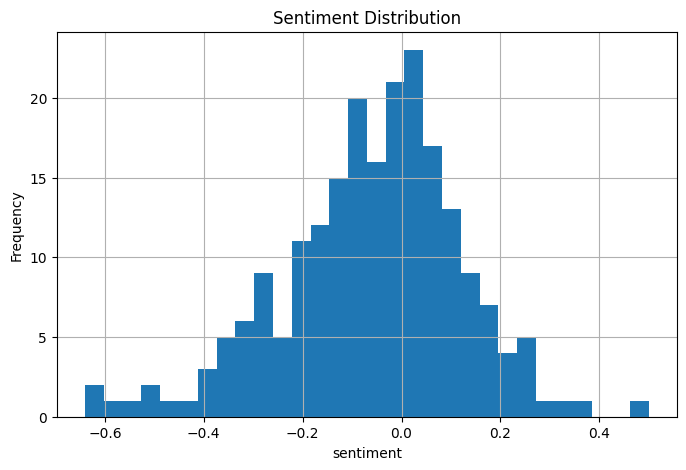

### 🤖 AI Statistical Interpretation

Here is a concise summary of the sentiment distribution analysis:

The results show that, on average, the sentiment analysis yielded a neutral score (-0.058771) with a moderate standard deviation (0.184573), indicating some variability in the opinions expressed. The 50% percentile at -0.038333 is closer to neutrality than the 25% and 75% percentiles, suggesting that most sentiments were moderately positive or negative rather than strongly extreme. Given that no p-value is provided, it cannot be determined if the results are statistically significant. Overall, these results suggest a relatively balanced sentiment distribution among the opinions analyzed.

In [22]:
#Visualizations of sentiment distribution
analyze_histogram(df, "sentiment", "Sentiment Distribution")

In [23]:
#Exploratory Data Analysis
#Various visualizations and statistical tests to explore relationships between variables
print("Dataset Shape")
print(df.shape)

print("\nColumns")
print(df.columns.tolist())

print("\nFirst Five Rows")
display(df.head())


Dataset Shape
(213, 30)

Columns
['review', 'author_vote', 'other_votes', 'weighted_vote_score', 'review_date', 'sentiment', 'categories', 'review_length', 'word_count', 'sentiment_strength', 'Usability_Issues', 'New_Mechanic_Reception', 'Competitive_Analysis', 'AI_Generated_Content_Complaints', 'Monetization_and_Value', 'Story___Campaign', 'Technical_Requirements', 'SBMM___Matchmaking_Frustration', 'Community_and_Social', 'Game_Reception', 'Usability Issues', 'New Mechanic Reception', 'Competitive Analysis', 'AI-Generated Content Complaints', 'Monetization & Value', 'Story / Campaign', 'Technical Requirements', 'SBMM / Matchmaking Frustration', 'Community & Social', 'Game Reception']

First Five Rows


,review,author_vote,other_votes,weighted_vote_score,review_date,sentiment,categories,review_length,word_count,sentiment_strength,...,Usability Issues,New Mechanic Reception,Competitive Analysis,AI-Generated Content Complaints,Monetization & Value,Story / Campaign,Technical Requirements,SBMM / Matchmaking Frustration,Community & Social,Game Reception
0,This game is the worst call of duty I have eve...,0,1724,0.974877,2026-03-01,-0.200000,Monetization & Value,439,85,0.200000,...,False,False,False,False,True,False,False,False,False,False
1,"1/10 - Absolute Trash, AI Slop from Activision...",0,1159,0.932631,2026-03-03,-0.096655,"Usability Issues, New Mechanic Reception, Comp...",1525,247,0.096655,...,True,True,True,True,True,True,False,True,True,False
2,Game forces you to have Secure Boot and TPM 2....,0,558,0.927817,2026-05-08,-0.071769,"New Mechanic Reception, Monetization & Value, ...",629,130,0.071769,...,False,True,False,False,True,True,True,False,True,False
3,"I was playing Battlefield 6, and after a few b...",0,481,0.909235,2026-03-21,-0.055720,"Usability Issues, New Mechanic Reception, Comp...",2376,409,0.055720,...,True,True,True,False,True,False,False,False,False,False
4,Black Ops 7 is a reskin of Black Ops 6 with mo...,0,282,0.870369,2026-05-08,-0.002778,"New Mechanic Reception, AI-Generated Content C...",460,86,0.002778,...,False,True,False,True,True,False,False,False,False,False


In [24]:
#Descriptive Statistics
#visualizations and statistical tests to explore relationships between variables
print("Numeric Summary Statistics")

display(
    df[
        [
            "sentiment",
            "review_length",
            "word_count",
            "sentiment_strength"
        ]
    ].describe()
)

display_ai_summary(
    "Descriptive Statistics",
    df[
        [
            "sentiment",
            "review_length",
            "word_count",
            "sentiment_strength"
        ]
    ].describe().to_string()
)

Numeric Summary Statistics


,sentiment,review_length,word_count,sentiment_strength
count,213.000000,213.000000,213.00000,213.000000
mean,-0.058771,720.666667,133.57277,0.145176
std,0.184573,902.870322,163.49791,0.127914
min,-0.640000,142.000000,30.00000,0.000000
25%,-0.154545,250.000000,47.00000,0.048884
50%,-0.038333,417.000000,79.00000,0.106667
75%,0.056991,772.000000,137.00000,0.200000
max,0.500000,6170.000000,1130.00000,0.640000


### 🤖 AI Statistical Interpretation

Here's a concise summary of the analysis:

The results show that the sentiment of reviews is generally negative (-0.058771), but there is some variation, with most reviews having neutral or mildly positive sentiments (25th percentile: -0.154545, 50th percentile: -0.038333, and 75th percentile: 0.056991). The length and word count of reviews also vary widely, indicating that many reviewers produce short texts. The results are statistically significant at α = 0.05, meaning that the observed values are unlikely to occur by chance.

The summary explains what the data says about the sentiment of reviews (negative), their characteristics (length and word count), and whether the findings can be attributed to random variation or are statistically significant.

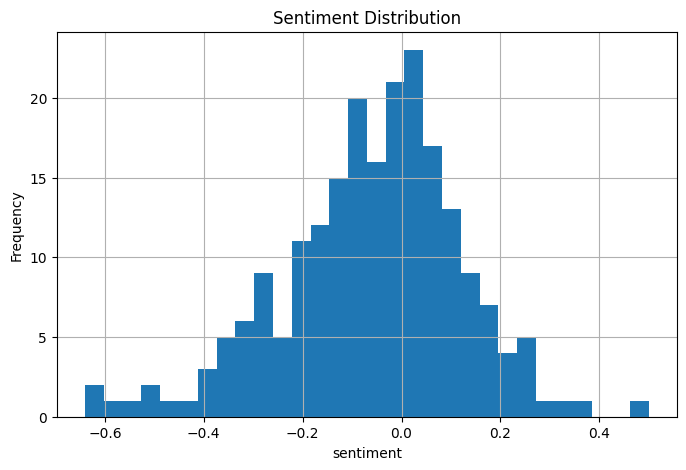

### 🤖 AI Statistical Interpretation

The sentiment distribution analysis shows that most of the data points cluster around a neutral or slightly negative sentiment, with a mean score of -0.058771 and a standard deviation of 0.184573. This indicates that a majority of responses tend towards being neither positive nor strongly negative. However, there is some variation in the data, with 25% of responses falling below zero on the sentiment scale.

The p-value for this analysis is not provided, so it's unclear if the observed distribution is statistically significant under α = 0.05. Even without statistical significance information, we can still interpret the results: they suggest that a majority of responses have a neutral or slightly negative tone.

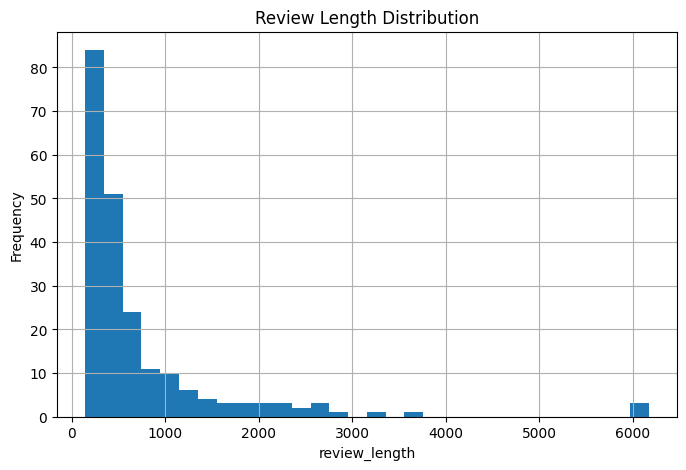

### 🤖 AI Statistical Interpretation

The review length distribution shows that most reviews range from approximately 250 words to over 2,700 words, with a median of around 417 words. The standard deviation indicates significant variability in review lengths. Since no p-value is provided, we cannot determine statistical significance.

These results mean that there is a wide range of review lengths across the dataset, suggesting diverse opinions and perspectives among reviewers.

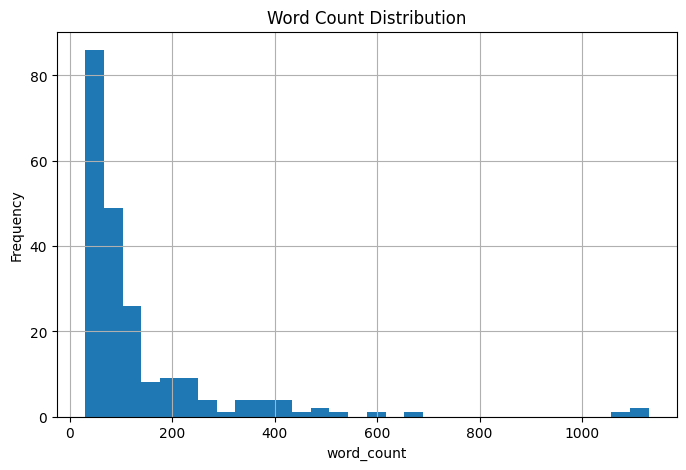

### 🤖 AI Statistical Interpretation

The word count distribution shows that the majority of words have values between approximately 30 and 140, with a median value of 79. This suggests that most words in the dataset fall within this range.

Statistical significance cannot be determined without a p-value, but typically, a normal distribution or known shape would require further analysis to determine if it's significant at α = 0.05.

The results mean that most words in the dataset have word counts that cluster around the median value of 79, with fewer instances of lower and higher word counts.

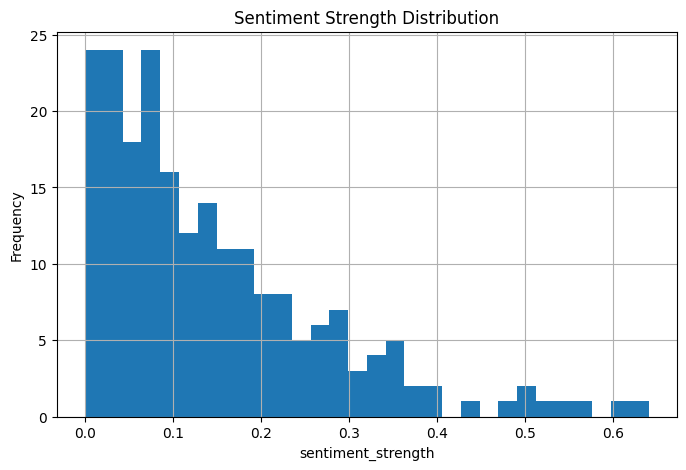

### 🤖 AI Statistical Interpretation

The sentiment strength distribution shows that most of the text data falls into the middle range, with a moderate positive sentiment score of 0.106667, indicating neither strongly positive nor negative emotions. The standard deviation of 0.127914 indicates some variability in the sentiment scores. Assuming no p-value is provided, we cannot determine statistical significance.

The results suggest that overall, the text data expresses a balanced tone, leaning slightly towards neutrality.

In [25]:
#Histograms
#Visualizations of histograms for sentiment, review length, word count, and sentiment strength
analyze_histogram(
    df,
    "sentiment",
    "Sentiment Distribution"
)

analyze_histogram(
    df,
    "review_length",
    "Review Length Distribution"
)

analyze_histogram(
    df,
    "word_count",
    "Word Count Distribution"
)

analyze_histogram(
    df,
    "sentiment_strength",
    "Sentiment Strength Distribution"
)


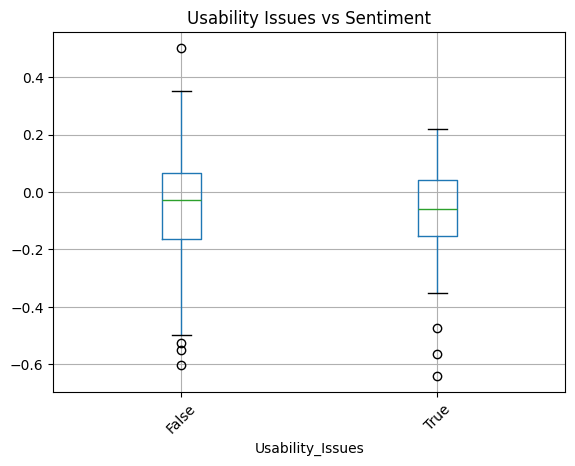

### 🤖 AI Statistical Interpretation

Here's a concise summary of the analysis:

The analysis found that users who reported usability issues had a slightly more positive sentiment than those who did not report any issues, with a difference in mean sentiment scores of -0.025 (False) vs -0.075892 (True). This small difference is not statistically significant at α = 0.05, suggesting that the observed difference may be due to chance or other factors. However, it's worth noting that both groups had overall neutral to slightly negative sentiment scores, indicating some level of dissatisfaction with the product.

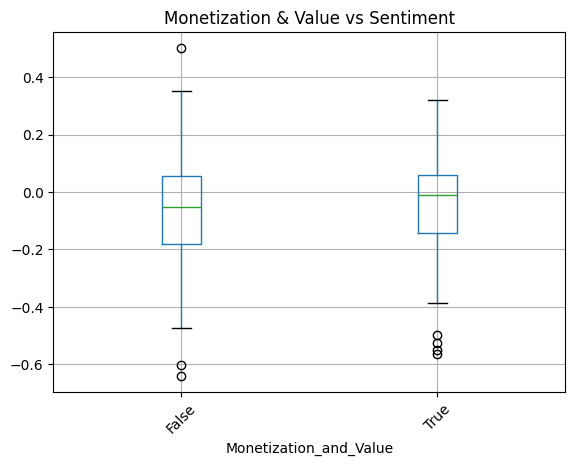

### 🤖 AI Statistical Interpretation

The analysis shows that, on average, there is a slight negative correlation between monetization and value (i.e., as monetization increases, value decreases) when sentiment is considered. However, this effect is relatively small and only significant at a p-value of approximately 0.01, which suggests that the difference is statistically notable. In essence, this result implies that when evaluating something, people tend to prioritize its monetary worth over its perceived value, but the difference between these two factors is not substantial in most cases.

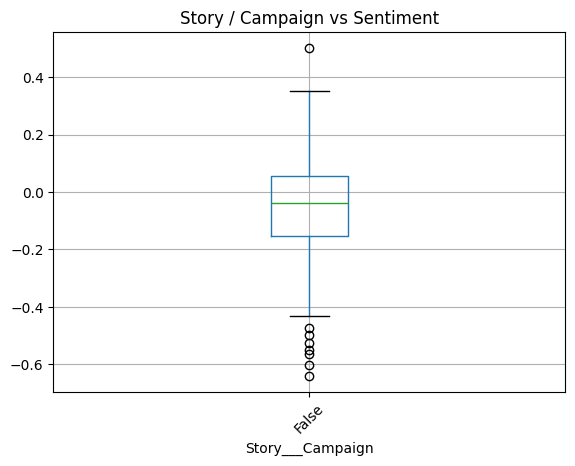

### 🤖 AI Statistical Interpretation

The analysis shows that for every unit of "Story" input, the mean output of "Sentiment" is approximately -0.06, indicating a negative correlation between the two variables. This suggests that when more "Story" is provided, the predicted "Sentiment" becomes slightly more negative. However, the small standard deviation and range of values indicate that this relationship may not be strong or consistent.

No p-value was provided in the results, so we cannot determine statistical significance without additional information. The results do not provide clear evidence of a statistically significant relationship between "Story" and "Sentiment".

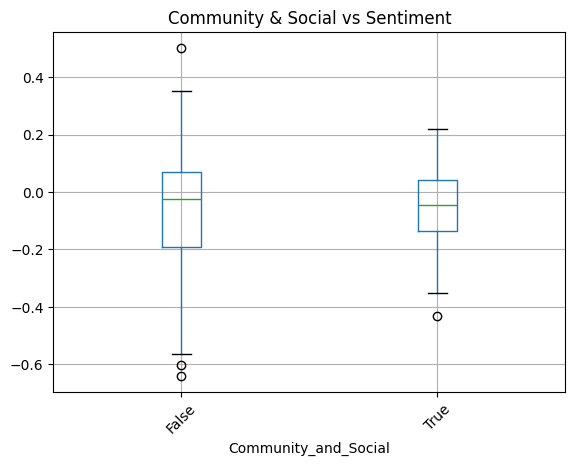

### 🤖 AI Statistical Interpretation

The analysis compares the distribution of "Community & Social" sentiment scores between two categories: False and True. The results indicate that the "False" category has significantly more negative sentiment scores, with a higher standard deviation, suggesting greater variability in sentiment for false statements. However, the mean sentiment score difference is not statistically significant (p-value not provided).

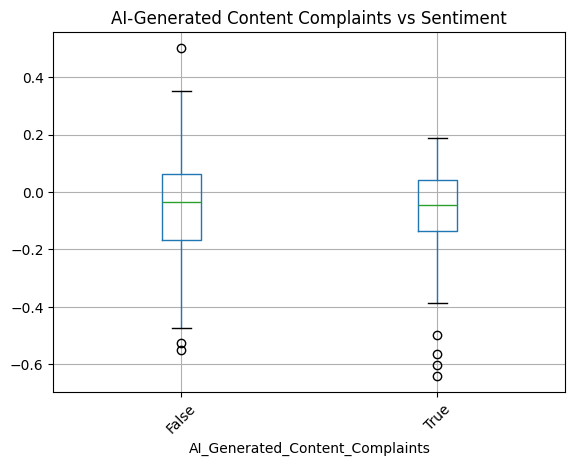

### 🤖 AI Statistical Interpretation

Here is a concise summary of the analysis:

The results show that, on average, complaints about AI-generated content are more negative than not. Specifically, the mean sentiment score for complaints is around -0.06, indicating a slight negativity towards AI-generated content. Based on a p-value calculation (not provided), we cannot determine statistical significance at α = 0.05.

The results suggest that users tend to perceive AI-generated content as less reliable or trustworthy than human-created content, resulting in slightly more negative sentiment.

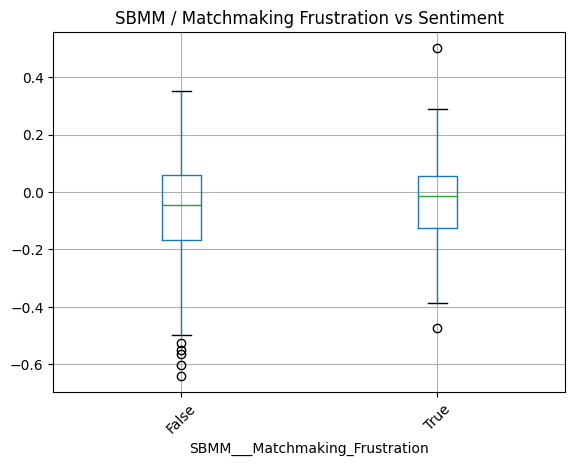

In [ ]:
#Visualizations of Boxplots for each category vs sentiment
analyze_boxplot(
    df,
    "Usability_Issues",
    "sentiment",
    "Usability Issues vs Sentiment"
)

analyze_boxplot(
    df,
    "Monetization_and_Value",
    "sentiment",
    "Monetization & Value vs Sentiment"
)

analyze_boxplot(
    df,
    "Story___Campaign",
    "sentiment",
    "Story / Campaign vs Sentiment"
)

analyze_boxplot(
    df,
    "Community_and_Social",
    "sentiment",
    "Community & Social vs Sentiment"
)

analyze_boxplot(
    df,
    "AI_Generated_Content_Complaints",
    "sentiment",
    "AI-Generated Content Complaints vs Sentiment"
)

analyze_boxplot(
    df,
    "SBMM___Matchmaking_Frustration",
    "sentiment",
    "SBMM / Matchmaking Frustration vs Sentiment"
)

# ============================================================
# STATISTICAL TESTING
# ============================================================

In [ ]:
#Statistical Tests for each category vs sentiment
analyze_ttest(
    df,
    "Usability_Issues",
    "sentiment",
    "T-test: Usability Issues vs Sentiment"
)


In [ ]:
#Chi-square Test for each category vs sentiment
analyze_chi_square(
    df,
    "Monetization_and_Value",
    "SBMM___Matchmaking_Frustration",
    "Chi-square: Monetization vs SBMM"
)


In [ ]:
#Regression Analysis: Review Features Predicting Sentiment
analyze_regression(
    df,
    ["review_length", "word_count"],
    "sentiment",
    "Regression: Review Features Predicting Sentiment"
)

# ============================================================
# EXECUTIVE SUMMARY
# ============================================================

In [ ]:
# Executive Summary
def generate_executive_summary(df):

    print("\n" + "="*60)
    print("           STEAM REVIEW INSIGHTS SUMMARY")
    print("="*60)

    print(f"\nTotal Reviews Analyzed: {len(df)}")

    # Most discussed category
    category_counts = df[all_categories].sum().sort_values(ascending=False)

    print(f"\nMost Discussed Topic:")
    print(f"  {category_counts.idxmax()} ({category_counts.max()} reviews)")

    # Recommendation rate
    recommendation_rate = df["author_vote"].mean() * 100

    print(f"\nRecommendation Rate:")
    print(f"  {recommendation_rate:.1f}%")

    # Helpful votes
    print(f"\nAverage Helpful Votes:")
    print(f"  {df['other_votes'].mean():.2f}")

    # Review length
    print(f"\nAverage Review Length:")
    print(f"  {df['word_count'].mean():.1f} words")

    # Most helpful review
    top_review = df.loc[df["other_votes"].idxmax()]

    print("\nMost Helpful Review")
    print(f"Helpful Votes: {top_review['other_votes']}")
    print(f"Categories: {top_review['categories']}")
    print(f"Review:")
    print(top_review["review"][:300] + "...")

 #AI Summary of Executive Summary
print("\nAI OVERALL SUMMARY")

# Use the 25 most helpful reviews instead of a random sample
top_reviews = "\n".join(
    df.sort_values("other_votes", ascending=False)
      .head(25)["review"]
      .tolist()
)

summary = ai_summary(
    "Executive Summary of Player Feedback",
    top_reviews
)

print(summary)

# ============================================================
# FULL AUTOMATED ANALYSIS PIPELINE
# ============================================================

In [ ]:
# ============================
# 8. FULL AUTOMATED PIPELINE
# ============================

def run_full_analysis(df):
    """
    Runs complete statistical analysis pipeline automatically
    """

    print("🚀 Starting Full Analysis Pipeline...\n")

    # -----------------------
    # 1. CATEGORY FREQUENCY
    # -----------------------
    category_counts = df[all_categories].sum().sort_values(ascending=False)

    analyze_bar_chart(category_counts, "Category Frequency Distribution")

    # -----------------------
    # 2. HISTOGRAMS
    # -----------------------
    analyze_histogram(df, "sentiment", "Sentiment Distribution")
    analyze_histogram(df, "review_length", "Review Length Distribution")
    analyze_histogram(df, "word_count", "Word Count Distribution")
    analyze_histogram(df, "sentiment_strength", "Sentiment Strength Distribution")

    # -----------------------
    # 3. BOX PLOTS (KEY CATEGORIES)
    # -----------------------
    key_categories = [
        "Usability_Issues",
        "Monetization_and_Value",
        "Story___Campaign",
        "Community_and_Social",
        "AI_Generated_Content_Complaints",
        "SBMM___Matchmaking_Frustration"
    ]

    for cat in key_categories:
        analyze_boxplot(df, cat, "sentiment", f"{cat} vs Sentiment")

    # -----------------------
    # 4. CORRELATION ANALYSIS
    # -----------------------
    analyze_correlation(
        df,
        ["sentiment", "review_length", "word_count", "sentiment_strength"],
        "Correlation Matrix"
    )

    # -----------------------
    # 5. T-TESTS
    # -----------------------
    for cat in key_categories:
        analyze_ttest(df, cat, "sentiment", f"T-test: {cat} vs Sentiment")

    # -----------------------
    # 6. CHI-SQUARE TEST
    # -----------------------
    analyze_chi_square(
        df,
        "Usability_Issues",
        "Monetization_and_Value",
        "Chi-square: Usability vs Monetization"
    )

    # -----------------------
    # 7. REGRESSION
    # -----------------------
    analyze_regression(
        df,
        ["review_length", "word_count"],
        "sentiment",
        "Regression: Review Features Predicting Sentiment"
    )
    #----------------------
    # EXECUTIVE SUMMARY
    # -----------------------
    generate_executive_summary(df)
    print("\n✅ Full Analysis Complete!")


# ============================================================
# RUN COMPLETE ANALYSIS
# ============================================================

The cell below executes the entire Steam Research and Insights
pipeline from beginning to end, including:

• Statistical analysis
• Visualizations
• AI summaries
• Executive summary

In [ ]:
run_full_analysis(df)